<a href="https://colab.research.google.com/github/arthurflor23/handwritten-text-recognition/blob/master/tutorial.ipynb" target="_parent"><img src="https://img.shields.io/badge/Colab-F9AB00?style=for-the-badge&logo=googlecolab&color=525252" alt="Open In Colab"/></a>
<a href="https://ko-fi.com/arthurflor23" target="_parent"><img src="https://img.shields.io/badge/Ko--fi-F16061?style=for-the-badge&logo=ko-fi&logoColor=white" alt="Support on Ko-fi"/></a>


<a href="https://github.com/arthurflor23/handwritten-text-recognition" target="_parent">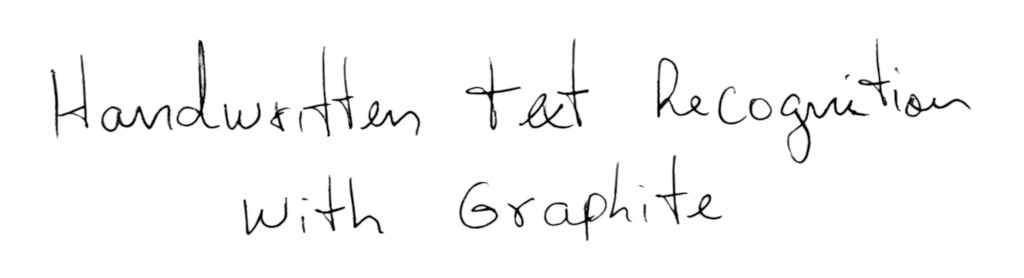</a>


# Handwritten Text Recognition with Graphite


## 1\. Introduction


In this tutorial, we'll be exploring [Graphite](https://github.com/arthurflor23/handwritten-text-recognition), an efficient and versatile solution for Handwritten Text Recognition (HTR). We'll guide you through the process of setting up your environment and preparing your datasets. Then, we'll delve into model training, prediction, evaluation, and samples. This will give you insights into the project, enabling you to apply what you learn to your own context. Also, if you're inspired to contribute, your ideas and improvements are welcome. Let's enhance Graphite together!


## 2\. Data Environment


In this section, we will set up the data environment to ensure a smooth execution of the Handwritten Text Recognition process. We'll cover the datasets you'll be working with and how to incorporate custom datasets into Graphite.


### 2\.1\. Datasets


Graphite offers native support for a wide range of datasets for Handwritten Text Recognition. The following datasets are already integrated into the Graphite project and can be readily used for training and evaluation:

1. [Bentham](https://drive.google.com/file/d/1JTF7itNMavb81EUTDRkUAUbsJ1wQx_Mw/view?usp=sharing) [[1]](https://doi.org/10.1109/DAS.2014.23)

2. [IAM](https://drive.google.com/file/d/1-_tFR64Tko7ICnZMIdwUQraXAYd028R2/view?usp=drive_link) [[2]](https://doi.org/10.1007/s100320200071)

3. [ORAND-CAR-A](https://drive.google.com/file/d/15deBvabYivvR4-z7K4GJGlP81Xdvu9-T/view?usp=drive_link) [[3]](https://doi.org/10.1109/ICFHR.2014.136)

4. [ORAND-CAR-B](https://drive.google.com/file/d/15deBvabYivvR4-z7K4GJGlP81Xdvu9-T/view?usp=drive_link) [[3]](https://doi.org/10.1109/ICFHR.2014.136)

5. [ORAND-CVL-DIGITS](https://drive.google.com/file/d/15deBvabYivvR4-z7K4GJGlP81Xdvu9-T/view?usp=drive_link) [[3]](https://doi.org/10.1109/ICFHR.2014.136)

6. [Parzival](https://drive.google.com/file/d/1EYv33klUY_tnLMbZ07I_upEdTZAkv_58/view?usp=drive_link) [[4]](http://dx.doi.org/10.1109/ICDAR.2011.20)

7. [Rimes](https://drive.google.com/file/d/1Hjnc_cYzzPg88382pvP04skjsq6acQGa/view?usp=drive_link) [[5]](https://hal.science/hal-01395332)

8. [Saint Gall](https://drive.google.com/file/d/1o3hvTBcr-h6S45mT9vDWKRokFN9Rqfis/view?usp=drive_link) [[6]](https://dl.acm.org/doi/10.1145/2037342.2037348)

9. [Washington](https://drive.google.com/file/d/150I0IcSWsjikYARuBBqmjrRQwukwSzRh/view?usp=drive_link) [[7]](http://dx.doi.org/10.1016/j.patrec.2011.09.009)


To use these datasets, ensure that they are placed in the `./data/` folder with their default names. This folder structure allows for seamless integration with Graphite and ensures that the datasets are easily accessible during the training and evaluation processes.

In addition, you can also incorporate other custom datasets by following the same folder structure and naming conventions. Feel free to explore these datasets or incorporate your own to tailor the HTR system to your specific requirements.


## 3\. Colab Environment


Setting up the Colab environment properly is essential to leverage the power of TensorFlow with GPU acceleration and access your project files conveniently through Google Drive. This section covers the necessary steps to ensure a correct setup.


### 3\.1\. TensorFlow with GPU


To check if your Colab environment has GPU support, execute the `!nvidia-smi` command. This command displays detailed information about the available GPUs, including their memory usage and utilization. Running this command helps you verify if your Colab environment has GPU access and ensures optimal performance during training and inference.


Execute the following command:


In [ ]:
!nvidia-smi

The output will show GPU information if your Colab environment has GPU support. If you don't see any GPU information, it means that GPU access may not be available at the moment. You can still proceed with the tutorial, but note that certain computations may be slower without GPU acceleration.


### 3\.2\. Google Drive


To mount your Google Drive in Colab and access your project files, execute the following code snippet:


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

This code will prompt you to authenticate and generate an authorization code. Click on the provided link and sign in with your Google account. This process will mount your Google Drive and make it accessible within the Colab environment.


After mounting your Google Drive, you can navigate to your project folder using the `cd` command. Adapt the command below with the actual path to your project folder:


In [ ]:
%cd "./drive/MyDrive/Colab Notebooks/handwritten-text-recognition/"

To verify that you are in the correct directory and see the list of files, execute the following command:


In [ ]:
!ls -l

Finally, to ensure all the required packages and dependencies are installed, make sure the `./requirements.txt` file is present in your project folder and execute the following command:


In [ ]:
!pip install -q -U -r requirements.txt

## 4\. Dataset Class


The Dataset class manages the data source and provides options for handling the dataset. Here are the descriptions of some parameters:

-   `source`: Name of the data source (e.g., 'bentham', 'iam', 'rimes').
-   `level`: Recognition granularity ('character', 'word', 'line', 'paragraph').
-   `training_ratio`: Ratio of data used for training.
-   `validation_ratio`: Ratio of data used for validation during training.
-   `test_ratio`: Ratio of data used for testing the trained model.
-   `lazy_mode`: Flag indicating if lazy mode is enabled (loads data in batches).
-   `artifact_path`: Path where the data is stored.
-   `seed`: Seed for random shuffles.

To create a dataset, we will use the "washington" dataset as the source and set the level to "line". Here's the code to create it:


In [ ]:
from graphite import Dataset


dataset = Dataset(source='washington',
                  level='line',
                  training_ratio=None,
                  validation_ratio=None,
                  test_ratio=None,
                  lazy_mode=False,
                  artifact_path='data',
                  seed=42)

dataset

**Note:** It's worth mentioning that if you want to integrate a custom source, create a new file (`<CUSTOM_SOURCE>.py`) in the `./graphite/dataset/source/` folder. It's important to follow the same pattern as the already implemented sources. Then, you can use it by specifying the `source` parameter as "custom_source" when creating the Dataset object.


## 5\. Augmentor Class


The Augmentor class applies various transformations to images for data augmentation purpose. Here are the descriptions of some parameters:

- `erode`: Apply erode transformation (probability, kernel size, iterations).
- `dilate`: Apply dilate transformation (probability, kernel size, iterations).
- `elastic`: Apply elastic transformation (probability, kernel size, alpha).
- `perspective`: Apply perspective transformation (probability, alpha).
- `mixup`: Apply mixup transformation (probability, opacity, iterations).
- `shear`: Apply shear transformation (probability, angle).
- `scale`: Apply scale transformation (probability, scale alpha).
- `rotate`: Apply rotate transformation (probability, angle).
- `shift_y`: Apply vertical translation (probability, y-alpha).
- `shift_x`: Apply horizontal translation (probability, x-alpha).
- `salt_and_pepper`: Apply Salt and Pepper noise (probability, alpha).
- `gaussian_noise`: Apply Gaussian noise (probability, alpha).
- `gaussian_blur`: Apply Gaussian blur (probability, kernel size, iterations).
- `seed`: Seed for random values from numpy.

To use the Augmentor class, you can create an instance and provide the desired parameters. The values in the list for each parameter define the specific settings for that transformation. Modify these values according to your augmentation requirements. Here's the code to create it:


In [ ]:
from graphite import Augmentor


augmentor = Augmentor(erode=[0.99, 5, 1],
                      dilate=[0.99, 2, 1],
                      elastic=[0.99, 43, 0.75],
                      perspective=[0.99, 0.4],
                      mixup=[0.99, 0.3, 1],
                      shear=[0.99, 30],
                      scale=[0.99, 0.05],
                      rotate=[0.99, 0.5],
                      shift_y=[0.99, 0.025, 0.05],
                      shift_x=[0.99, 0.025, 0.05],
                      salt_and_pepper=[0.99, 0.5],
                      gaussian_noise=[0.99, 0.75],
                      gaussian_blur=[0.99, 11, 1],
                      seed=42)

augmentor

## 6\. Model Class


The Model class manages the optical model for Handwritten Text Recognition system. Here are the descriptions of some class parameters:

-   `network`: Name of the network module for the model architecture.
-   `experiment_name`: MLflow experiment name for model tracking.
-   `artifact_path`: Path name to track model artifacts.
-   `seed`: Seed for tensorflow operations.

After creating the model instance, you can compile the model using the `compile` method. This method takes the following parameters:

-   `tokenizer`: The Tokenizer object used for tokenizing the input data.
-   `learning_rate`: The learning rate for the optimizer in the model.
-   `run_index`: The run index to load the context from. Can be used to continue some training, for example.

We'll use the "flor" as the optical model and set the experiment name to "Tutorial". Here's the code to create and compile it:

In [ ]:
from graphite import Model


model = Model(network='flor', experiment_name='Tutorial', artifact_path='mlruns', seed=42)

model.compile(tokenizer=dataset.tokenizer, learning_rate=1e-3, run_index=None)

model

**Note:** Just like creating a custom source, if you want to integrate a custom network, create a new file (`<CUSTOM_NETWORK>.py`) in the `./graphite/model/network/` folder. It's important to follow the same pattern as the already implemented networks to ensure consistency within the Graphite project. Then, you can use it by specifying the `network` parameter as "custom_network" when creating the Model object.


### 6\.1\. Model Training

In this subsection, we'll cover the process of training the optical model using the specified dataset and augmentor. The following code snippet demonstrates the steps involved in model training:

In [ ]:
# Set the training parameter values
epochs = 1000
batch_size = 8
plateau_factor = 0.5
plateau_cooldown = 0
plateau_patience = 10
patience = 20

# Generate training and validation data generators
train_data, train_steps = dataset.get_generator(partition=dataset.training,
                                                batch_size=batch_size,
                                                augmentor=augmentor)

valid_data, valid_steps = dataset.get_generator(partition=dataset.validation,
                                                batch_size=batch_size,
                                                augmentor=None)

# Fit the model
model.fit(epochs=epochs,
          training_data=train_data,
          training_steps=train_steps,
          validation_data=valid_data,
          validation_steps=valid_steps,
          plateau_factor=plateau_factor,
          plateau_cooldown=plateau_cooldown,
          plateau_patience=plateau_patience,
          patience=patience,
          verbose=1)

model.training_logger

Let's break down the steps:

1. **Generate Training and Validation Data Generators:** The `get_generator` method of the `Dataset` class is used to generate data generators for the training and validation sets. The `partition` parameter specify the corresponding dataset subset to be used. The `batch_size` parameter determines the number of samples per batch. The `augmentor` parameter is used to apply augmentation techniques to the training data. In this example, the `augmentor` is used for training data, while no augmentation is applied to the validation data by passing `augmentor=None`.

2. **Fit the Model:** The `fit` method of the `Model` class is used to train the model. The `epochs` parameter specifies the number of training epochs. The `training_data` and `validation_data` parameters accept the data generators generated in the previous step. The `training_steps` and `validation_steps` parameters specify the number of steps per epoch for training and validation, respectively. Other parameters such as `plateau_factor`, `plateau_cooldown`, `plateau_patience`, `patience`, and `verbose` control aspects of the training process.

Executing this code will initiate the training process for the optical model using the provided dataset, augmentation techniques, and specified training parameters. Feel free to adjust the parameters based on your specific requirements and dataset characteristics to achieve optimal model performance.

### 6\.2\. Model Prediction

In this subsection, we'll explore how to use the trained model to make predictions on test data. Thus, after training the optical model, we'll use it for making predictions on unseen data. The following code snippet demonstrates how to perform model prediction:

In [ ]:
# Set the test parameter values
top_paths = 1
beam_width = 30

# Generate test data generator
test_data, test_steps = dataset.get_generator(partition=dataset.test,
                                              batch_size=batch_size,
                                              shuffle=False)

# Perform predictions
predictions, probabilities = model.predict(test_data=test_data,
                                           test_steps=test_steps,
                                           top_paths=top_paths,
                                           beam_width=beam_width,
                                           ctc_decode=True,
                                           token_decode=True,
                                           verbose=1)

model.test_logger

Let's break down the steps:

1. **Generate Test Data Generator:** The `get_generator` method of the `Dataset` class is used to generate a data generator for the test dataset. The `partition` parameter specifies the test dataset subset, and the `batch_size` parameter determines the number of samples per batch.

2. **Perform Predictions:** The `predict` method of the `Model` class is used to make predictions on the test data. The `test_data` parameter accepts the data generator generated in the previous step. The `test_steps` parameter specifies the number of steps for the test dataset. Other parameters such as `top_paths`, `beam_width`, `ctc_decode`, `token_decode`, and `verbose` control aspects of the prediction process.

Executing this code will generate predictions using the trained optical model on the unseen test data. The predicted outputs will be stored in the `predictions` and `probabilities` variables. Feel free to adjust the parameters based on your specific requirements and desired prediction behavior.

### 6\.3\. Model Evaluation

In this subsection, we'll evaluate the model's performance by comparing its predictions against the ground truth labels. For that, pass the test dataset and the baseline predictions generated previously, and capture the metrics returned by the method.

In [ ]:
baseline_metrics = model.evaluate(partition=dataset.test, baseline_predictions=predictions)

model.evaluation_logger

**Note:** The `baseline_metrics` variable, obtained from `model.evaluate()`, stores performance metrics that can be used for various tasks. Meanwhile, the model's `evaluation_logger` provides pre-processed data about the evaluation.

## 7\. Spelling Class


Lastly, the Spelling class is responsible for checking and correcting spelling errors in text data. It provides methods to interact with a spell checker. Here is the description of the parameters used in this class:

-   `spell_checker`: The name of the spell checker to be used.
-   `api_key`: The API key to interact with the spell checker.
-   `env_key`: The key to access the environment variable that holds the API key
-   `dotenv_file`: The file name of the environment file.

To create an instance of the Spelling class, you need to provide the relevant parameters. For example:


In [ ]:
from graphite import Spelling


spelling = Spelling(spell_checker='openai',
                    api_key=None,
                    env_key=None,
                    dotenv_file='.env')

spelling

Please note that the spelling checker and API key used here are for illustration purposes. Replace them with the appropriate spell checker and API key based on your specific requirements. If you use the `.env` environment file, make sure you pass the `env_key` parameter, and the key will be loaded automatically.


**Note:** Just like creating a custom source or network, if you want to integrate a custom spell checker, create a new file (`<CUSTOM_SPELL_CHECKER>.py`) in the `./graphite/spelling/spellchecker/` folder. It's important to follow the same pattern as the already implemented spell checkers to ensure consistency within the Graphite project. Then, you can use it by specifying the `spell_checker` parameter as "custom_spell_checker" when creating the Spelling object.


### 7\.1\. Spelling Correction

Use the `spelling` to enhance the baseline predictions generated in the previous step. The method will iterate over the baseline predictions and apply the spelling correction mechanism provided by the Spelling class.


In [ ]:
spelling_predictions = spelling.enhance(predictions)

### 7\.2\. Spelling Evaluation

Evaluate the model's performance with spelling enhancement by using the evaluate method again. Pass the test dataset and the enhanced predictions with spelling correction, and capture the metrics returned by the method.


In [ ]:
spelling_metrics = model.evaluate(partition=dataset.test, spelling_predictions=spelling_predictions)

model.evaluation_logger

**Note:** The `spelling_metrics` variable, obtained from `model.evaluate()`, stores performance metrics that can be used for various tasks. Meanwhile, the model's `evaluation_logger` provides pre-processed data about the evaluation.

## 8\. Save Context


To keep track of the entire process, we can use the `save_context` method provided by the model.


In [ ]:
model.save_context(dataset=dataset,
                   augmentor=augmentor,
                   baseline_metrics=baseline_metrics,
                   spelling=spelling,
                   spelling_metrics=spelling_metrics)

Once the `save_context` method is called, MLflow will save all the relevant information, including the dataset, augmentor, model, training and testing details, metrics, and predictions. This information can then be easily accessed and tracked using the MLflow Tracking UI (`mlflow ui`).


## 9\. Samples


In this section, we'll visualize samples from the test dataset and compare the ground truth labels with the model's predictions. By iterating over the test data, we can examine the accuracy of the model's predictions on individual examples and gain insights into its performance.

For each sample, we'll display the ground truth label, the model's initial prediction, and the spelling-enhanced prediction. This visual comparison allows us to assess the effectiveness of the spelling correction functionality and observe any improvements made to the recognized text.


In [ ]:
import matplotlib.pyplot as plt


test_data, test_steps = dataset.get_generator(dataset.test)
pred_index = 0

for _ in range(test_steps):
    batch_data, batch_labels = next(test_data)

    for i in range(len(batch_data)):
        image = batch_data[i]
        label = dataset.tokenizer.decode(batch_labels[i])

        plt.figure(figsize=(12, 6))
        plt.imshow(image, cmap='gray')
        plt.axis('off')
        plt.show()

        print("\nTest Label")
        print('\n'.join(label))

        print("\nPrediction")
        print('\n'.join(predictions[0, pred_index, :]))

        print("\nSpelling Prediction")
        print('\n'.join(spelling_predictions[0, pred_index, :]))

        print("=" * 113)
        pred_index += 1